In [14]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import same_start as sst

RECORDINGS = Path("../../Assets/SimulationRecordings/Combinations/20260825_014231")
PRADIUS = 1.5
runs = sst.load_folder(RECORDINGS)

# One run, used for the whole notebook: dispersion, random 40, maxSpeed 1.5, perception 3.25.
run = sst.select(runs, speed=1.5, random=40, R=PRADIUS)[0]
t = np.asarray(run["times"], dtype=float)
a = np.asarray(run["areas"], dtype=float)
dt = float(np.median(np.diff(t)))

# Its no-randomness partner, from the identical spawn layout.
ref = sst.select(runs, speed=1.5, random=0, R=PRADIUS, layout=run["layout"])[0]
tr = np.asarray(ref["times"], dtype=float)
ar = np.asarray(ref["areas"], dtype=float)

print(f"run      : {run['path'].name}")
print(f"layout   : {run['layout']}")
print(f"frames   : {len(t)}   dt = {dt*1000:.2f} ms   ({1/dt:.0f} fps)")
print(f"area     : {a[0]:.1f} u² at t=0  ->  {a[-1]:.1f} u² at t={t[-1]:.1f}s")
print(f"reference: same layout, no randomness, settles at {ar[-1]:.1f} u²")

inv_radii = sorted({r["R"] for r in runs})

run      : type_dispersion_randommovement_40.00_perceptionrad_1.50_maxspeed_1.50_20260819_150007_layout_00.json
layout   : 20260819_150007_layout_00
frames   : 3582   dt = 17.00 ms   (59 fps)
area     : 25.9 u² at t=0  ->  371.7 u² at t=59.7s
reference: same layout, no randomness, settles at 120.3 u²


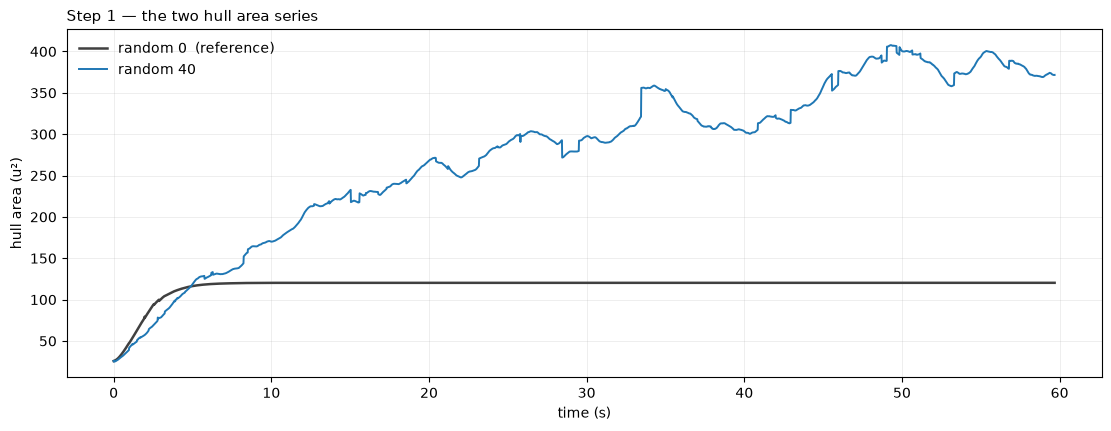

In [15]:
fig, ax = plt.subplots(figsize=(11, 4.2), layout="constrained")
ax.plot(tr, ar, color="#404040", lw=1.8, label="random 0  (reference)")
ax.plot(t, a, color="#1f77b4", lw=1.4, label="random 40")
ax.set_xlabel("time (s)"); ax.set_ylabel("hull area (u²)")
ax.grid(alpha=0.25, lw=0.6); ax.legend(frameon=False)
ax.set_title("Step 1 — the two hull area series", fontsize=11, loc="left")
plt.show()

In [16]:
i = int(np.searchsorted(t, 40.0))
table = pd.DataFrame({
    "t (s)":        t[i:i+6].round(3),
    "area (u²)":    a[i:i+6].round(2),
    "Δ area":       (a[i:i+6] - a[i-1:i+5]).round(2),
    "Δarea / Δt":   ((a[i:i+6] - a[i-1:i+5]) / dt).round(1),
})
display(table)

window = a[i:i+30]
print(f"across that half second the area moved {window[-1]-window[0]:+.1f} u² in total,")
print(f"but the frame-to-frame rate swings between "
      f"{np.min(np.diff(window)/dt):.0f} and {np.max(np.diff(window)/dt):+.0f} u²/s.")

,t (s),area (u²),Δ area,Δarea / Δt
0,40.000,303.44,-0.30,-17.6
1,40.017,303.18,-0.26,-15.2
2,40.033,302.86,-0.32,-18.8
3,40.050,302.60,-0.27,-15.8
4,40.066,302.38,-0.22,-12.9
5,40.083,302.09,-0.29,-16.8


across that half second the area moved -1.7 u² in total,
but the frame-to-frame rate swings between -19 and +14 u²/s.


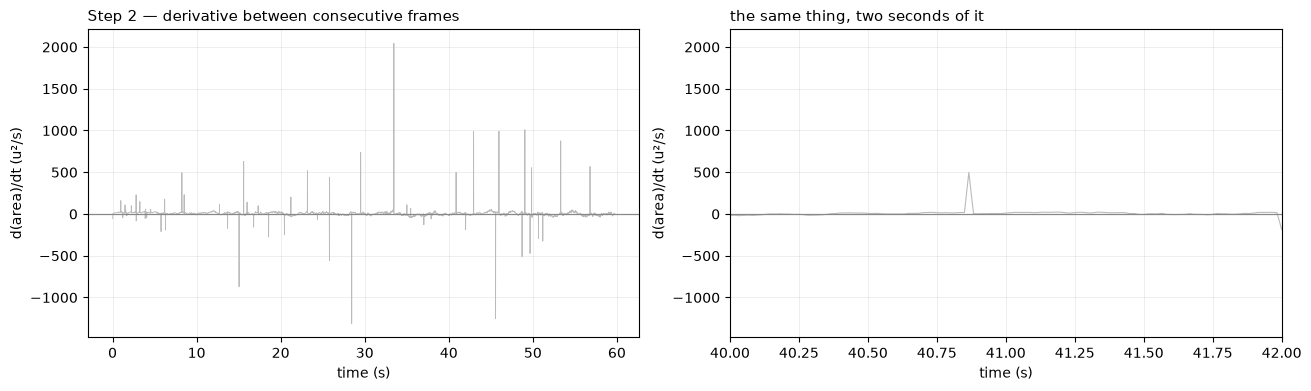

standard deviation of the per-frame derivative: 69 u²/s
The trend we are looking for is a few u²/s. It is completely buried.


In [17]:
per_frame = np.diff(a) / np.diff(t)

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8), layout="constrained")
ax[0].plot(t[1:], per_frame, color="#bbbbbb", lw=0.6)
ax[0].set_title("Step 2 — derivative between consecutive frames", fontsize=11, loc="left")
ax[1].plot(t[1:], per_frame, color="#bbbbbb", lw=0.8)
ax[1].set_xlim(40, 42); ax[1].set_title("the same thing, two seconds of it", fontsize=11, loc="left")
for x in ax:
    x.axhline(0, color="#888", lw=0.9); x.set_xlabel("time (s)")
    x.set_ylabel("d(area)/dt (u²/s)"); x.grid(alpha=0.25, lw=0.6)
plt.show()

print(f"standard deviation of the per-frame derivative: {per_frame.std():.0f} u²/s")
print("The trend we are looking for is a few u²/s. It is completely buried.")

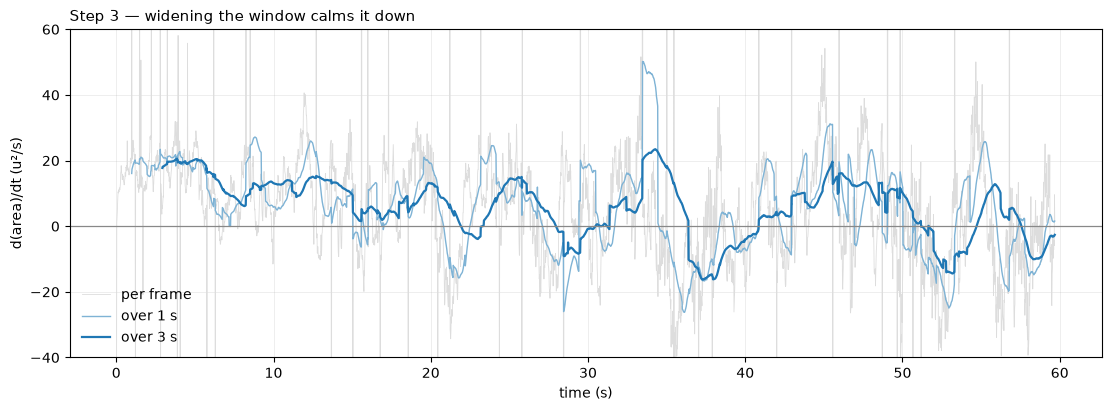

  window 1s: sd of the estimate = 13.33 u²/s
  window 3s: sd of the estimate =  8.90 u²/s


In [18]:
def boxcar(t, a, seconds):
    """Change in area over `seconds`, divided by that time. NaN until the window is filled."""
    w = max(2, int(round(seconds / dt)))
    out = np.full(len(a), np.nan)
    out[w:] = (a[w:] - a[:-w]) / (t[w:] - t[:-w])
    return out

fig, ax = plt.subplots(figsize=(11, 4.0), layout="constrained")
for secs, colour, lw in ((0.0, "#dddddd", 0.6), (1.0, "#7fb3d5", 1.0), (3.0, "#1f77b4", 1.6)):
    if secs == 0.0:
        ax.plot(t[1:], per_frame, color=colour, lw=lw, label="per frame")
    else:
        ax.plot(t, boxcar(t, a, secs), color=colour, lw=lw, label=f"over {secs:g} s")
ax.axhline(0, color="#888", lw=0.9)
ax.set_ylim(-40, 60); ax.set_xlabel("time (s)"); ax.set_ylabel("d(area)/dt (u²/s)")
ax.grid(alpha=0.25, lw=0.6); ax.legend(frameon=False)
ax.set_title("Step 3 — widening the window calms it down", fontsize=11, loc="left")
plt.show()

for secs in (1.0, 3.0):
    v = boxcar(t, a, secs); v = v[~np.isnan(v)]
    print(f"  window {secs:g}s: sd of the estimate = {v.std():5.2f} u²/s")

,area sd (u²),mean slope (u²/s),slope sd (u²/s)
run,,,
random 0 (reference),0.0,0.00,0.00
random 40,29.8,3.32,8.19


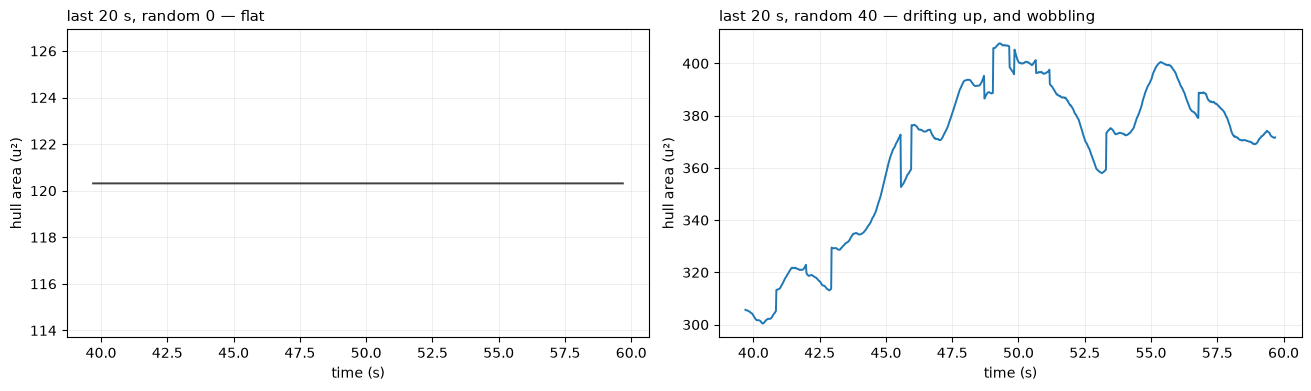

In [19]:
late = t > t[-1] - 20
late_r = tr > tr[-1] - 20

rows = []
for name, tt, aa, mask in (("random 0 (reference)", tr, ar, late_r), ("random 40", t, a, late)):
    v = boxcar(tt, aa, 3.0)
    v = v[mask & ~np.isnan(v)]
    rows.append({"run": name,
                 "area sd (u²)": round(float(aa[mask].std()), 2),
                 "mean slope (u²/s)": round(float(v.mean()), 2),
                 "slope sd (u²/s)": round(float(v.std()), 2)})
display(pd.DataFrame(rows).set_index("run"))

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8), layout="constrained")
ax[0].plot(tr[late_r], ar[late_r], color="#404040", lw=1.4)
ax[0].set_title("last 20 s, random 0 — flat", fontsize=11, loc="left")
ax[1].plot(t[late], a[late], color="#1f77b4", lw=1.4)
ax[1].set_title("last 20 s, random 40 — drifting up, and wobbling", fontsize=11, loc="left")
for x in ax:
    x.set_xlabel("time (s)"); x.set_ylabel("hull area (u²)"); x.grid(alpha=0.25, lw=0.6)
plt.show()

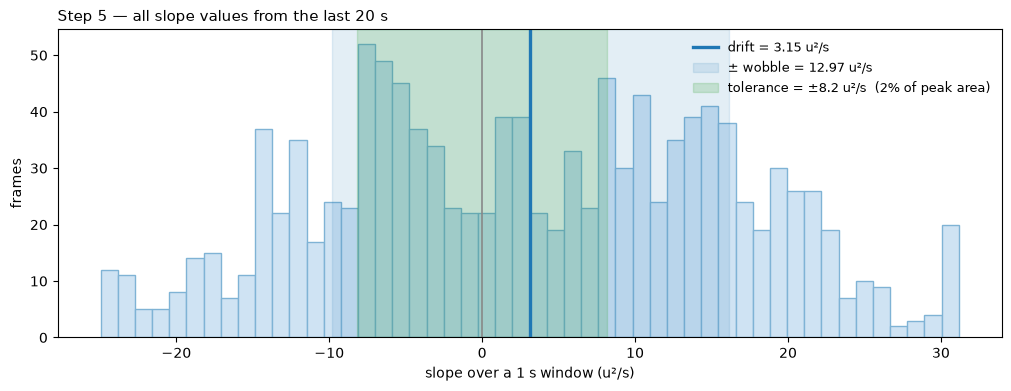

drift 3.15 u²/s     wobble 12.97 u²/s     tolerance ±8.2 u²/s
fraction of frames inside the tolerance band: 40%


In [20]:
tt, v1 = sst._smooth_derivative(t, a, 1.0)
late1 = tt > tt[-1] - 20
vals = v1[late1]
drift, wobble = float(vals.mean()), float(vals.std())
tol = 0.02 * a.max()

fig, ax = plt.subplots(figsize=(10, 3.8), layout="constrained")
ax.hist(vals, bins=50, color="#cfe3f3", edgecolor="#7fb3d5")
ax.axvline(0, color="#888", lw=1.2)
ax.axvline(drift, color="#1f77b4", lw=2.4, label=f"drift = {drift:.2f} u²/s")
ax.axvspan(drift - wobble, drift + wobble, color="#1f77b4", alpha=0.12,
           label=f"± wobble = {wobble:.2f} u²/s")
ax.axvspan(-tol, tol, color="#2ca02c", alpha=0.18,
           label=f"tolerance = ±{tol:.1f} u²/s  (2% of peak area)")
ax.set_xlabel("slope over a 1 s window (u²/s)"); ax.set_ylabel("frames")
ax.legend(frameon=False, fontsize=9)
ax.set_title("Step 5 — all slope values from the last 20 s", fontsize=11, loc="left")
plt.show()

print(f"drift {drift:.2f} u²/s     wobble {wobble:.2f} u²/s     "
      f"tolerance ±{tol:.1f} u²/s")
print(f"fraction of frames inside the tolerance band: {np.mean(np.abs(vals) <= tol):.0%}")

In [21]:
import steady_state as ss

rows = []
for R in [x for x in (0.90, 1.50, 2.00, 2.50, 3.25) if x in inv_radii]:
    for rnd in (40, 80):
        sel = sst.select(runs, speed=1.5, random=rnd, R=R)
        if not sel:
            continue
        tols, wobs, settled = [], [], []
        for p in sel:
            pt = np.asarray(p["times"], float); pa = np.asarray(p["areas"], float)
            ptt, pv = sst._smooth_derivative(pt, pa, 1.0)
            lastbit = ptt > ptt[-1] - 20
            tols.append(0.02 * pa.max())
            wobs.append(float(pv[lastbit].std()))
            settled.append(ss.find_plateau(pt, pa)["reached"])
        rows.append({"R": R, "random": rnd,
                     "tolerance": round(float(np.mean(tols)), 1),
                     "wobble": round(float(np.mean(wobs)), 1),
                     "tol / wobble": round(float(np.mean(tols) / np.mean(wobs)), 2),
                     "find_plateau settled": f"{np.mean(settled):.0%}"})

display(pd.DataFrame(rows).set_index(["R", "random"]))
print("The rule is not measuring whether the swarm settled. It is measuring whether this run's\n"
      "peak area happened to be large enough to buy a tolerance wider than its own wobble.")

tolerance  wobble  tol / wobble find_plateau settled
R    random                                                      
0.90 40            6.7    12.2          0.55                  80%
     80            3.9     7.7          0.51                  40%
1.50 40            7.5    13.7          0.55                  20%
     80            5.2     8.8          0.59                  40%
2.00 40            9.1    17.8          0.51                  20%
     80            6.3     9.9          0.63                  20%
2.50 40            9.8    13.8          0.71                  40%
     80            7.7     8.9          0.87                  60%
3.25 40           11.7    11.7          1.00                 100%
     80            9.7     9.5          1.02                  80%

The rule is not measuring whether the swarm settled. It is measuring whether this run's
peak area happened to be large enough to buy a tolerance wider than its own wobble.


In [22]:
rows = []
for secs in (1, 2, 3, 5, 8, 12):
    ttw, vw = sst._smooth_derivative(t, a, float(secs))
    lastbit = ttw > ttw[-1] - 20
    vv = vw[lastbit]
    rows.append({"window (s)": secs,
                 "drift": round(float(vv.mean()), 2),
                 "wobble": round(float(vv.std()), 2),
                 "drift / wobble": round(float(vv.mean() / vv.std()), 2),
                 "% inside tolerance": f"{np.mean(np.abs(vv) <= tol):.0%}"})
display(pd.DataFrame(rows).set_index("window (s)"))

,drift,wobble,drift / wobble,% inside tolerance
window (s),,,,
1,3.15,12.97,0.24,40%
2,3.17,9.77,0.32,50%
3,3.32,8.19,0.41,52%
5,3.10,6.53,0.47,69%
8,2.75,5.21,0.53,78%
12,3.63,2.48,1.46,97%


## Step 6. What smoothing does, and what it does not

 Savitzky–Golay fits a small polynomial across the window and reads the slope off the fit.


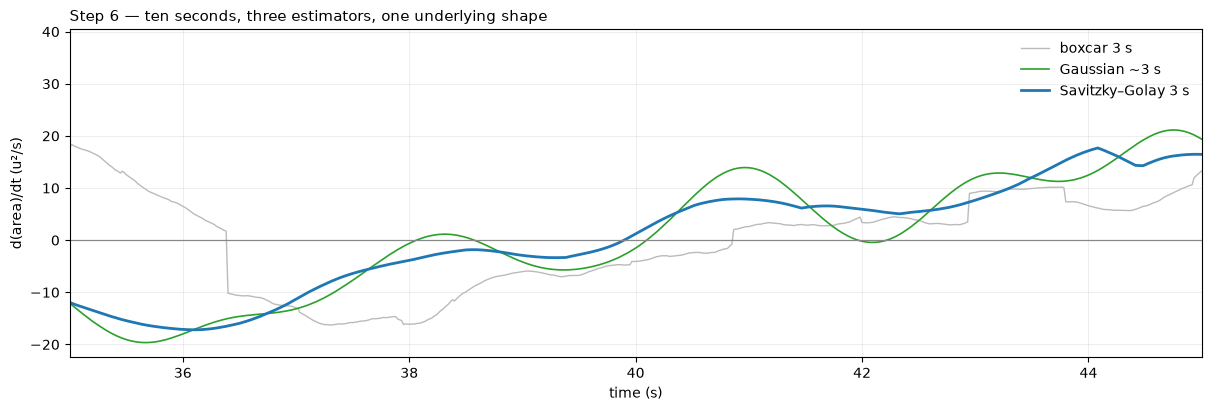

,drift,wobble,rattle
estimator,,,
boxcar 3 s,3.32,8.19,0.614
Gaussian ~3 s,3.25,9.89,0.214
Savitzky–Golay 3 s,3.31,8.69,0.143


In [23]:
from scipy.ndimage import gaussian_filter1d

sg = sst.savgol_drift(t, a, 3.0, 2)
gs = gaussian_filter1d(a, sigma=(3.0/dt)/6.0, order=1, mode="nearest") / dt
bx = boxcar(t, a, 3.0)

fig, ax = plt.subplots(figsize=(12, 4.0), layout="constrained")
ax.plot(t, bx, color="#bbbbbb", lw=1.0, label="boxcar 3 s")
ax.plot(t, gs, color="#2ca02c", lw=1.2, label="Gaussian ~3 s")
ax.plot(t, sg, color="#1f77b4", lw=2.0, label="Savitzky–Golay 3 s")
ax.axhline(0, color="#888", lw=0.9)
ax.set_xlim(35, 45); ax.set_xlabel("time (s)"); ax.set_ylabel("d(area)/dt (u²/s)")
ax.grid(alpha=0.25, lw=0.6); ax.legend(frameon=False)
ax.set_title("Step 6 — ten seconds, three estimators, one underlying shape",
             fontsize=11, loc="left")
plt.show()

rows = []
for name, v in (("boxcar 3 s", bx), ("Gaussian ~3 s", gs), ("Savitzky–Golay 3 s", sg)):
    vv = v[late & ~np.isnan(v)]
    rows.append({"estimator": name,
                 "drift": round(float(vv.mean()), 2),
                 "wobble": round(float(vv.std()), 2),
                 "rattle": round(float(np.std(np.diff(vv))), 3)})
display(pd.DataFrame(rows).set_index("estimator"))

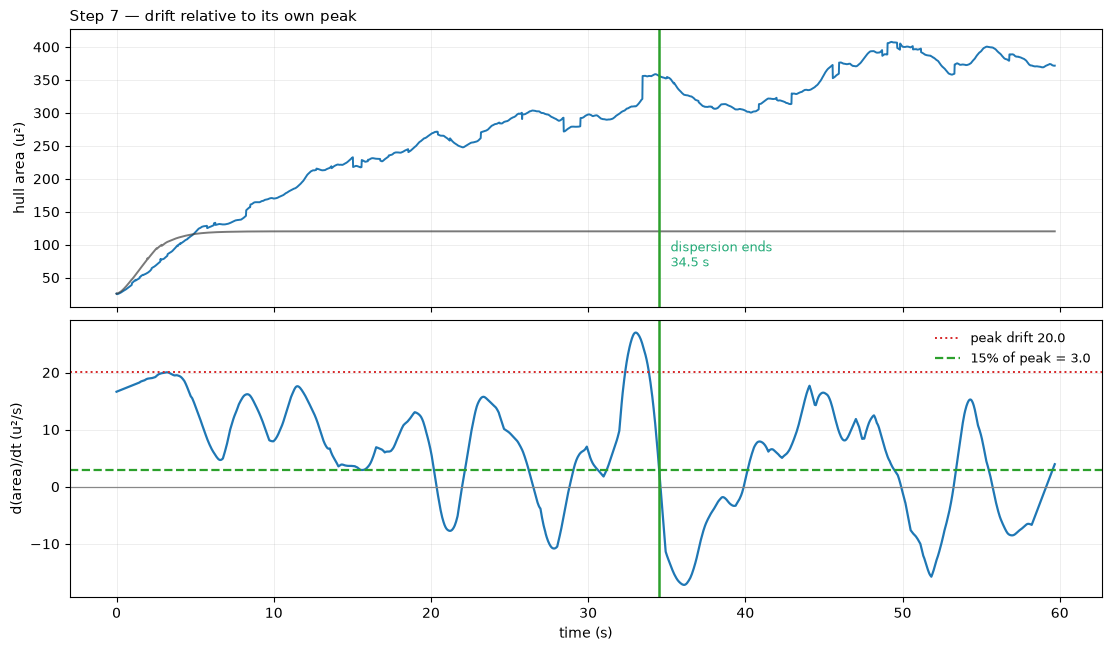

dispersion ends at 34.5s, with the hull at 356 u²
after that the hull still rises to 372 u²  (+4%) — that part is random motion, not dispersion


In [24]:
peak = float(np.nanmax(sg[t <= t[-1] * 0.5]))
limit = 0.15 * peak
result = sst.dispersion_end(run)

fig, ax = plt.subplots(2, 1, figsize=(11, 6.4), sharex=True, layout="constrained")
ax[0].plot(t, a, color="#1f77b4", lw=1.4)
ax[0].plot(tr, ar, color="#404040", lw=1.4, alpha=0.7)
ax[0].set_ylabel("hull area (u²)")

ax[1].plot(t, sg, color="#1f77b4", lw=1.6)
ax[1].axhline(peak,  color="#d62728", ls=":", lw=1.4, label=f"peak drift {peak:.1f}")
ax[1].axhline(limit, color="#2ca02c", ls="--", lw=1.6, label=f"15% of peak = {limit:.1f}")
ax[1].axhline(0, color="#888", lw=0.9)
ax[1].set_ylabel("d(area)/dt (u²/s)"); ax[1].set_xlabel("time (s)")

if result["fires"]:
    for x in ax:
        x.axvline(result["time"], color="#2ca02c", lw=1.8)
    ax[0].annotate(f"dispersion ends\n{result['time']:.1f} s", (result["time"], a.min()),
                   xytext=(8, 20), textcoords="offset points", fontsize=9, color="#2a7")

for x in ax:
    x.grid(alpha=0.25, lw=0.6)
ax[1].legend(frameon=False, fontsize=9)
ax[0].set_title("Step 7 — drift relative to its own peak", fontsize=11, loc="left")
plt.show()

if result["fires"]:
    j = result["index"]
    print(f"dispersion ends at {result['time']:.1f}s, with the hull at {a[j]:.0f} u²")
    print(f"after that the hull still rises to {a[-1]:.0f} u²  "
          f"({(a[-1]-a[j])/a[j]:+.0%}) — that part is random motion, not dispersion")

In [25]:
def fires_at(tt, aa, estimator, frac=0.15, hold=3.0):
    d = estimator(tt, aa)
    early = d[tt <= tt[-1] * 0.5]
    pk = float(np.nanmax(early)) if len(early) else 0.0
    if pk <= 0:
        return None
    need = max(1, int(round(hold / dt)))
    streak = 0
    for k, value in enumerate(d):
        if not np.isnan(value) and value <= frac * pk:
            streak += 1
            if streak >= need:
                return float(tt[k - need + 1])
        else:
            streak = 0
    return None

estimators = {
    "boxcar 1 s":         lambda tt, aa: boxcar(tt, aa, 1.0),
    "boxcar 3 s":         lambda tt, aa: boxcar(tt, aa, 3.0),
    "Gaussian ~3 s":      lambda tt, aa: gaussian_filter1d(aa, sigma=(3.0/dt)/6.0,
                                                           order=1, mode="nearest") / dt,
    "Savitzky–Golay 3 s": lambda tt, aa: sst.savgol_drift(tt, aa, 3.0, 2),
    "Savitzky–Golay 5 s": lambda tt, aa: sst.savgol_drift(tt, aa, 5.0, 3),
}

peers = sst.select(runs, speed=1.5, random=40, R=3.25)
rows = []
for name, fn in estimators.items():
    times = [x for x in (fires_at(np.asarray(p["times"], float),
                                  np.asarray(p["areas"], float), fn) for p in peers)
             if x is not None]
    rows.append({"estimator": name,
                 "fired": f"{len(times)}/{len(peers)}",
                 "mean (s)": round(float(np.mean(times)), 1) if times else None,
                 "sd across layouts (s)": round(float(np.std(times)), 1) if times else None})

display(pd.DataFrame(rows).set_index("estimator"))
print("Report this as an interval and name the filter. Do not quote it to the decimal.")

,fired,mean (s),sd across layouts (s)
estimator,,,
boxcar 1 s,4/5,35.0,7.7
boxcar 3 s,5/5,24.7,5.4
Gaussian ~3 s,5/5,32.8,7.3
Savitzky–Golay 3 s,5/5,27.8,9.3
Savitzky–Golay 5 s,5/5,27.8,9.5


Report this as an interval and name the filter. Do not quote it to the decimal.


In [26]:
inline = sst.savgol_drift(t, a, 3.0, 2)
library = sst.savgol_drift(run["times"], run["areas"], 3.0, 2)
print("inline vs library identical:", np.allclose(inline, library, atol=1e-12))

box_here = boxcar(t, a, 1.0)
_, box_lib = sst._smooth_derivative(t, a, 1.0)
overlap = min(len(box_lib), len(box_here) - (len(box_here) - len(box_lib)))
print("boxcar matches steady_state's window difference:",
      np.allclose(box_here[len(box_here)-len(box_lib):], box_lib, atol=1e-9))

inline vs library identical: True
boxcar matches steady_state's window difference: True
